# Logistic Regression 

정석적인 설명은 아니다. 

느낌만!

토익, 텝스 예제로 돌아오자. 

In [1]:
import rpy2
%load_ext rpy2.ipython

In [136]:
%%R 
set.seed(9999)
n<-1000
toeic<-750+rnorm(n,sd=80)
toeic[toeic>990]<-990
toeic<-round(toeic)
gpa<-3.5+rnorm(n,sd=0.3)
gpa[gpa>4.5]<-4.5 
gpa<-round(gpa,1)
sal<-gpa*600+toeic*5+rnorm(n,sd=80)
sal<-round(sal)

In [137]:
%%R 
head(sal)

[1] 6276 5979 5910 5758 7098 6344


데이터를 조금 바꾸어서 $y$를 연봉이 아니라 합격 or 불합격으로 생각하자. 

In [138]:
%%R
mean(sal)

[1] 5854.538


구 예제에서 연봉이 5850미만인 사람은 불합격이라고 가정하고, 연봉이 5850이상인 사람은 합격이라고 하자 

In [139]:
%%R 
set.seed(3)
n<-1000
toeic<-750+rnorm(n,sd=80)
toeic[toeic>990]<-990
toeic<-round(toeic)
gpa<-3.5+rnorm(n,sd=0.3)
gpa[gpa>4.5]<-4.5 
gpa<-round(gpa,1)
temp<-gpa*600+toeic*5+rnorm(n,sd=80)
employed<- (temp>5850)*1

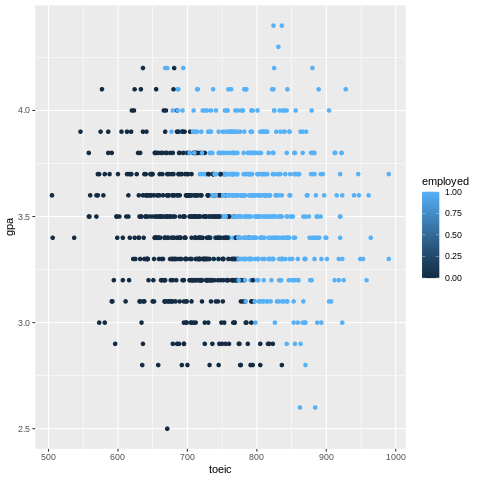

In [140]:
%%R
library(tidyverse)
tb<-tibble(toeic=toeic,gpa=gpa,employed=employed)
library(ggplot2)
ggplot(data=tb,aes(x=toeic,y=gpa))+geom_point(aes(col=employed))

## 1. Structure: Step function $\to$ Sigmoid function

진짜모형: 

(1) 학점이 높을수록 그리고 토익점수가 높을수록 합격할 확률이 높다. 

(2) 구체적으로는 아래와 같다. 
 - `(gpa*600 +toeic*5 + 랜덤) > 5850` 이면 합격
 - `(gpa*600 +toeic*5 + 랜덤) =< 5850` 이면 불합격

(3) 식으로 엄밀하게 써보면 아래와 같다. 

모든 $i=1,\dots,1000$에 대하여

$y_i = I(x_{i1}\times 600 + x_{2i}\times 5 +\epsilon_i > 5850)$

정리하면 

$y_i = I(x_{i1}\times 600 + x_{2i}\times 5 +\epsilon_i - 5850 >0)$

단, $I(x>0)=\begin{cases}1 & x>0 \\ 0 & x \leq 0  \end{cases}$.

(4) 우리는 $data=\big\{(x_{i1},x_{i2},y_i)\big\}_{i=1}^{1000}$를 알고 있고, data로 부터 추론할것은 바로

- 600 
- 5
- -5850

이라는 숫자들이다. 

(5) 논의를 편하게 하기 위해서 앞으로는 600이라는 값을 알고 있다고 가정하자. 그리고 5와 5500을 추론하기만 하면 된다고 하자. 

(6) 문제는 아래와 같이 단순화 된다.

모든 $i=1,2,\dots,5850$에 대하여 

$
y_i=I(x_{i1}\beta_1+x_{i2}\times 5 +\epsilon_i > \gamma)
$

에서 $\beta_1$, $\gamma$를 추론해야 한다. $\epsilon_i$은 운적인 요소이므로 추론의 대상이 아님. 따라서

$
y_i\approx I(x_{i1}\beta_1+x_{i2}\times 5  > \gamma)
$

가 되도록 $\hat{\beta}_1$와 $\hat{\gamma}$을 잘 추론해야 한다. 

최소제곱법을 사용하자. 아래와 같은 손실함수 $L$을 정의하자. 

$L=\sum_{i=1}^{1000}\big(y_i-I(x_{i1}\beta_1+x_{i2}\times 5  > \gamma)\big)^2$

$L$을 최소화하는 $\beta_1$, $\gamma$를 구하자.

일반적으로 $L$을 각각 $\beta_1$, $\gamma$로 미분한뒤 그 값을 0으로 놓은 식을 연립하여 풀면 된다. 즉 아래를 풀면된다.

$\begin{cases}
\frac{\partial }{\partial \beta_1}L=0\\ 
\frac{\partial }{\partial \gamma}L=0
\end{cases}$

먼저 $\frac{\partial}{\partial \beta_1}L=0$을 살펴보자. 

$L=\big(y_1-I(x_{11}\beta_1+x_{12}\times 5  > \gamma)\big)^2+ \dots + \big(y_n-I(x_{n1}\beta_1+x_{n2}\times 5  > \gamma)\big)^2$, 단 $n=1000$.

미분하려고 보니까 $I$는 미분이 불가능한 함수이다. 

???

### 문제점: 미분을 못한다. 

우리는 뭘 연립해서 풀어야 하는가? 

### 해결책1

수치해석적인 노가다

가능한 모든 $\beta_1$과 $\gamma$의 조합을 생각한다. 

그리고 아래를 계산한다. 

$L=\sum_{i=1}^{n}\big(y_i-I(\beta_1x_{i1}+5x_{i2}-\gamma>0)\big)^2$

예를들어 $\beta_1=0.2$, $\gamma=200$을 넣고 위의 값을 계산할 수 있다. 편의상 그 값을 $L(0.2,200)$라고 하자. 

그리고 $\beta_1=10$, $\gamma=5000$을 넣고 계산할 수도 있다. 편의상 그 값을 $L(10,5000)$이라고 하자. 

우연히 $\beta_1=600$, $\gamma=5500$을 넣는다면 그 조합이 $L$을 최소화 할 것이다. 

즉 $L(600,5500)$이 $L(\beta,\gamma)$의 조합중 최소값일 것이다. 

### 해결책2 

미분불가능한함수를 미분가능한 어떤 함수로 바꾼다. 

미분 불가능한 부분은 현재 아래와 같은 함수의 형태이다. 

$
I(\beta_1x_{i1}+5x_{i2}-\gamma>0)
$

예를들어서 $i=1$이라고 치면 아래와 같은 함수이다.

$
I(\beta_1x_{11}+5x_{12}-\gamma>0)
$

그런데

$x_{11}=3.1$, $x_{12}=673$ 이므로 

In [128]:
%R print(gpa[1])
%R print(toeic[1])

[1] 3.1
[1] 673


array([673.])

아래와 같이 정리가능

$
I(\beta_1\times 3.1+5\times 673-\gamma>0)
$

이 함수의 모양은 계단형이다. 



(1) $\beta_1$을 고정 $\to$ $x$축에 $\gamma$, $y$축에 $I(\beta_1\times 3.1+5\times 673-\gamma>0)$를 그리면 계단모양이 된다. 

(2) $\gamma$을 고정 $\to$ $x$축에 $\beta_1$, $y$축에 $I(\beta_1\times 3.1+5\times 673-\gamma>0)$를 그리면 계단모양이 된다. 

***case1: beta1를 고정***

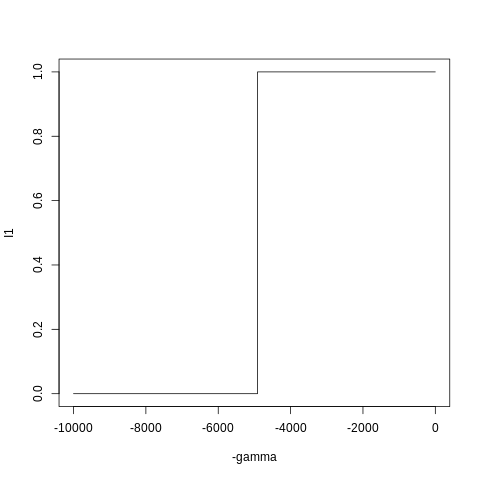

In [130]:
%%R
beta1=500
gamma=1:10000
I1 = 1*(gpa[1]*beta1+toeic[1]*5-gamma>0)
plot(-gamma,I1,type='l')

***case2: gamma를 고정***

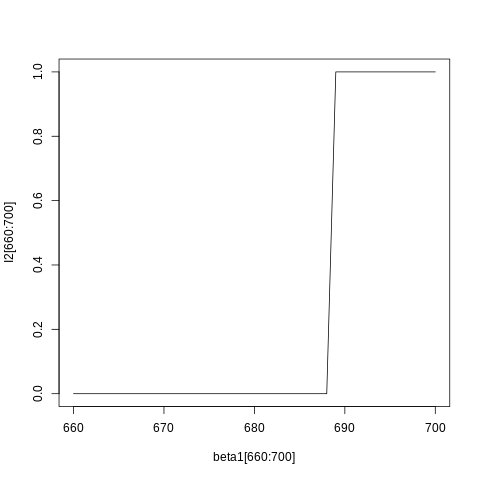

In [131]:
%%R
gamma=5500
beta1=1:1000
I2=1*(gpa[1]*beta1+toeic[1]*5-gamma>0)
plot(beta1[660:700],I2[660:700],type='l')

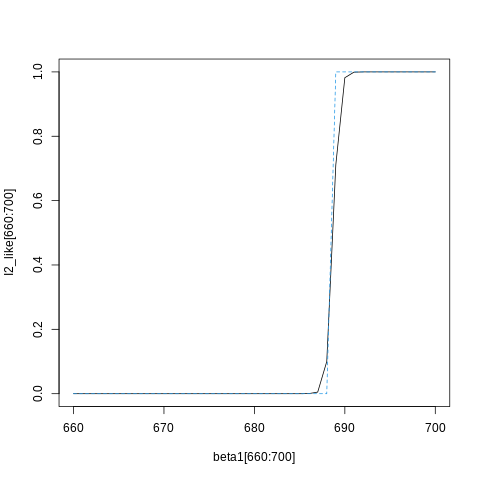

In [132]:
%%R 
gamma=5500
beta1=1:1000
yy<- gpa[1]*beta1+toeic[1]*5-gamma
I2_like<-exp(yy)/(1+exp(yy))
plot(beta1[660:700],I2_like[660:700],type='l')
lines(beta1[660:700],I2[660:700],col=4,lty=2)

비슷하다. 

${\tt yy}_i=x_{i1}\beta_1+x_{i2}\times 5 -\gamma$

${\tt I2like}=\frac{exp(x_{i1}\beta_1+x_{i2}\times 5-\gamma)}{1+exp(x_{i1}\beta_1+x_{i2}\times 5-\gamma)}$

---

원래 트루모형: 

$y_i=f(\beta_0+x_{i1}\beta_1+x_{i2}\beta_2+\epsilon_i)$

$f(x)=I(x)$

제안하는 모형:

$y_i=f(\beta_0+x_{i1}\beta_1+x_{i2}\beta_2+\epsilon_i)$

$f(x)=\frac{e^x}{1+e^x}=\frac{1}{1+e^{-x}}$

왜? 

(1) $\frac{e^x}{1+e^x}$는 $x$로 미분이 가능하며 

(2) 원래모형과 별 차이가 없다. 

---

## 2. Error term

통: 위의 설명은 전체적으로 틀렸다. 

X: 왜 그런가? 

통: 손실함수를 오차제곱합으로 잡는것 자체가 말이 안된다. LSE를 쓴다는것 자체가 말이 안된다. 

X: 왜 LSE가 이상한 것인가? 

통: 애초에 오차를 왜 제곱하는지 모르겠다. 오차를 제곱하는것은 원래 MLE에서 기원한다. 오차항이 정규분포일때는 LSE를 구하는것이 합리적이다. 

- Estimator의 성능을 평가하고자 할때 기준이 명확해야 하는 법이다. 
- 그 기준이 오차항의 분포가 명시되어 있으면 명확한 편인데 그것이 바로 최대우도추정량이다. 
- 오차항의 분포를 가정하고 우리가 추정하고 싶은 것을 MLE로 추정을 해야 정석적임. 
- 오차항이 정규분포라고 하자. 정규분포의 pdf는 아래와 같은 형태. 
$
f(x)=\frac{1}{\sigma\sqrt{2\pi}}\exp\big(-\frac{(x-\mu)^2}{2\sigma^2}\big)
$
- 로그 우도함수를 구하면 나머지는 상수처리되고 $\exp\big(\dots \big)$안의 `제곱꼴`의 함수만 남음. 

X: 그래서 이 경우에는 MLE를 어떻게 구할수 있는가? 

통: 손실함수를 아래와 같이 바꾸어라. (아래와 같은 손실함수를 크로스-엔트로피라고 한다.)

$\sum_{i=1}^{n} - \big(y_i\log(p_i)+(1-y_i)\log(1-p_i)\big)$

X: 그런데 그냥 LSE를 쓰면 안될까? 

---

아래의 예제를 생각해보자. 

```
데이터과학 "모의고사"에서 O X 를 맞추는 문제가 4개 나왔다고 하자. 
답은 O O X X 라고 하자. 
답이 O라면 1을 쓰고 답이 X라면 0을 쓰라고 강사가 주문했다고 하자. (정답은 1 1 0 0) 
O인지 X인지 헷갈리는데 답이 O인것 같다.. 그 확신이 약 0.7정도.. 0.7이라고 답안을 써도 괜찮다고 하자. 
```

> ***학생이 답지를 입력하면*** 입력한 전체답안에 대한 피드백을 준다. 단 어떠한 문제를 맞추고 못맞추었는지는 알려주지 않는다. 

```
학생1의 정답: 0.5 0.5 0.5 0.5 ### 그냥 찍는 학생 
학생2의 정답: 0.5 0.6 0.5 0.5 ### 학생1보다는 약간 나은학생
학생3의 정답: 1 1 1 0 ### 자신감있음. 하지만 한문제가 완벽하게 틀림. 
학생4의 정답: 1 1 0 0 ### 완벽한 정답
```

--- 

아래와 같은 손실함수를 고려하자. 

${\tt Loss1}: \sum_{i=1}^{4}(y_i-p_i)^2$

${\tt Loss2}: \sum_{i=1}^{4}-\big(y_i\log p_i +(1-y_i)\log(1-p_i)\big)$

In [141]:
%%R 
loss1<-function(p){
    (1-p[1])^2+ (1-p[2])^2+(0-p[3])^2+(0-p[4])^2
}
loss2<-function(p){
    -(log(p[1])+log(p[2])+log(1-p[3])+log(1-p[4]))
}

#### 손실함수2의 특징: ***다 맞추고 한 문제라도 틀리면 손실이 무한대값.***

#### 학생1 - 손실함수2 

In [101]:
%%R 
p<-c(0.5,0.5,0.5,0.5)
loss2(p)
#-log(0.5)-log(0.5)-log(0.5)-log(0.5)

[1] 2.772589


#### 학생2 - 손실함수2 

In [109]:
%%R 
p<-c(0.5,0.6,0.5,0.5)
loss2(p)

[1] 2.590267


#### 학생3 - 손실함수2 

In [107]:
%%R 
p<-c(1,1,1,0)
loss2(p)

[1] Inf


???

#### 학생4 - 손실함수2 

In [106]:
%%R 
p<-c(1,1,0,0)
loss2(p)

[1] 0


---

손실함수2의 특징
- 아무것도 모르는 학생이 뭔가를 배우면서 정답에 가까워진다면 적절한 보상을 줌. (학생1 $\to$ 학생2). 이상적인 지도. 
- **차라리 아무것도 모르는 학생1에게는 나름 친절함. 거의 다 아는데, 하나의 틀린답을 가진 학생에게 매우 가혹함. 심한채찍질을 함.**


***상황1***

In [114]:
%%R 
library(tidyverse)
p<-c(1,1,1,0); print(str_c(loss1(p),'  ,  ',loss2(p)))
p<-c(1,1,0.999,0); print(str_c(loss1(p),'  ,  ',loss2(p)))

[1] "1  ,  Inf"
[1] "0.998001  ,  6.90775527898214"


***상황2***

In [115]:
%%R 
library(tidyverse)
p<-c(1,1,1,0); print(str_c(loss1(p),'  ,  ',loss2(p)))
p<-c(1,1,0.999,0.001); print(str_c(loss1(p),'  ,  ',loss2(p)))

[1] "1  ,  Inf"
[1] "0.998002  ,  6.90875577931572"


***상황3***

In [116]:
%%R 
library(tidyverse)
p<-c(1,1,1,0); print(str_c(loss1(p),'  ,  ',loss2(p)))
p<-c(1,1,0.999,0.1); print(str_c(loss1(p),'  ,  ',loss2(p)))

[1] "1  ,  Inf"
[1] "1.008001  ,  7.01311579463996"


---

#### 손실함수1이 가지는 약점: convex (볼록함수) 가 되지 않음. 

- 파라메터를 추정하기 위해서는 $L$이 파라메터 $\beta$에 대하여 convex function이어야 한다. 
- 우리가 사실 지금까지 다루었던것은 선형모형이다. 
- 이 내용에 대하여서는 추후에 더 자세하게 다룰예정 

### 로지스틱 회귀분석: 프로그래밍 예제

#### Toy Example
- 8명의 학생이 있다고 생각하고 8명의 학생에 대한 학점, 텝스, 합격여부가 기록된 데이터를 임의로 만듦

#### Step1: 자료확보

In [4]:
import numpy as np
toeic=np.array([750,900,850,
               450,400,500,
               700,700])
gpa=np.array([3.8,4.0,4.5,
             2.8,2.5,2.2,
             3.4,3.6])
employed=np.array([1,1,1,
                  0,0,0,
                  1,0])

In [5]:
toeic,gpa,employed

(array([750, 900, 850, 450, 400, 500, 700, 700]),
 array([3.8, 4. , 4.5, 2.8, 2.5, 2.2, 3.4, 3.6]),
 array([1, 1, 1, 0, 0, 0, 1, 0]))

- 총 8명의 학생이 있음. 
- 학생 1,2,3은 토익/학점 모두 우수함 $\to$ 합격
- 학생 4,5,6은 그렇지 않음 $\to$ 불합격
- 학생 7,8은 합격과 불합격의 경계에 있는 학생들임. 
    - 학생 7,8을 비교하면 토익점수는 동일하고 gpa는 학생8이 0.2가 높다. 
    - 단순비교하면 학생8이 합격해야할것 같지만, 실제로는 학생8은 불합격 학생7이 합격함. 

#### Step2: X,y 재정의

In [6]:
X=np.array([toeic,gpa]).transpose()
y=employed

In [7]:
X.shape

(8, 2)

In [8]:
y.shape

(8,)

- $X$: $8 \times 2$ matrix 
- $y$: length $8$ vector

#### Step3: 데이터 전처리

데이터 전처리: 기계가 학습하기 좋은 형태로 데이터를 가공하는 과정을 의미

In [9]:
from sklearn.preprocessing import *
onehot=OneHotEncoder()
mms=MinMaxScaler()

In [10]:
mms.fit(X)
X=mms.transform(X)

In [11]:
onehot.fit(y.reshape(-1,1))
y=onehot.transform(y.reshape(-1,1)).toarray()

In [12]:
X,y

(array([[0.7       , 0.69565217],
        [1.        , 0.7826087 ],
        [0.9       , 1.        ],
        [0.1       , 0.26086957],
        [0.        , 0.13043478],
        [0.2       , 0.        ],
        [0.6       , 0.52173913],
        [0.6       , 0.60869565]]),
 array([[0., 1.],
        [0., 1.],
        [0., 1.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [0., 1.],
        [1., 0.]]))

***note:전처리 이후에 $y$의 차원이 $8 \times 2$ matrix로 변화***

#### Step4: 모델을 설정

**[필요한 패키지 로드]**

In [13]:
import tensorflow as tf

**[레이어를 설정]**

In [14]:
l1=tf.keras.layers.Dense(2,input_shape=(2,),activation='softmax')

- `2`: 출력층의 차원을 의미 ($y$는 $8\times 2$ matrix)
- `input_shape=(2,)`: 입력의 차원이 2라는 의미임. (toeic, gpa) 이므로.. 
- `activation='softmax'`: activation 함수를 의미함. 우리의 경우는 $f(x)=\frac{e^x}{1+e^x}$를 의미함. 이 예제의 경우 `softmax`를 옵션으로 주면 원하는 결과를 얻는다. 

**[레이어를 여러장 조합하여 모형구축]**

In [15]:
m1=tf.keras.models.Sequential() ## 모델의 틀을 만들고 
m1.add(l1) ## 모델에 레이어 `l1`를 추가함. 
m1.summary() ## 구축된 모형을 요약하여 보여줌. 

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 2)                 6         
Total params: 6
Trainable params: 6
Non-trainable params: 0
_________________________________________________________________


#### Step5: 모델컴파일 (손실함수설정) 

In [16]:
m1.compile(loss='categorical_crossentropy')

#### Step6: 학습 ($\hat{\beta}$을 구하는 과정)

In [17]:
m1.fit(X,y) #m1.fit(X,y,epochs=1)

1/1 [==============================] - 0s 767us/step - loss: 0.9781


#### Step6: 예측

In [18]:
m1.predict(X),y

(array([[0.72881186, 0.27118808],
        [0.7837002 , 0.21629976],
        [0.79194474, 0.20805532],
        [0.5580901 , 0.4419099 ],
        [0.51811993, 0.4818801 ],
        [0.5393707 , 0.4606293 ],
        [0.6902784 , 0.30972153],
        [0.70140105, 0.2985989 ]], dtype=float32),
 array([[0., 1.],
        [0., 1.],
        [0., 1.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [0., 1.],
        [1., 0.]]))

In [19]:
m1.weights

[<tf.Variable 'dense/kernel:0' shape=(2, 2) dtype=float32, numpy=
 array([[ 0.5340973 , -0.28657287],
        [ 0.45704448, -0.14736448]], dtype=float32)>,
 <tf.Variable 'dense/bias:0' shape=(2,) dtype=float32, numpy=array([-0.00316227,  0.00316227], dtype=float32)>]

이 값들을 한번에 예측할 수는 없다. 

--> 반복하면서 최적의 해로 다가가는 접근법을 선택. 

반복의 횟수: `epoch` 
    


지금은 한번의 반복만 한 상태임 즉 `epoch=1`인 상태임

반복을 추가하면 (=에폭을 늘리면) 점점 옳은 해로 나아갈것임. 

#### 반복수를 늘려서 다시 학습하자. 

In [20]:
m1.fit(X,y,epochs=10000)

Epoch 1/10000
1/1 [==============================] - 0s 794us/step - loss: 0.9739
Epoch 2/10000
1/1 [==============================] - 0s 517us/step - loss: 0.9708
Epoch 3/10000
1/1 [==============================] - 0s 505us/step - loss: 0.9683
Epoch 4/10000
1/1 [==============================] - 0s 505us/step - loss: 0.9661
Epoch 5/10000
1/1 [==============================] - 0s 497us/step - loss: 0.9641
Epoch 6/10000
1/1 [==============================] - 0s 571us/step - loss: 0.9622
Epoch 7/10000
1/1 [==============================] - 0s 508us/step - loss: 0.9604
Epoch 8/10000
1/1 [==============================] - 0s 597us/step - loss: 0.9587
Epoch 9/10000
1/1 [==============================] - 0s 568us/step - loss: 0.9571
Epoch 10/10000
1/1 [==============================] - 0s 767us/step - loss: 0.9555
Epoch 11/10000
1/1 [==============================] - 0s 496us/step - loss: 0.9540
Epoch 12/10000
1/1 [==============================] - 0s 475us/step - loss: 0.9525
Epoch 13/1000

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Epoch 1430/10000
1/1 [==============================] - 0s 592us/step - loss: 0.3416
Epoch 1431/10000
1/1 [==============================] - 0s 535us/step - loss: 0.3414
Epoch 1432/10000
1/1 [==============================] - 0s 590us/step - loss: 0.3412
Epoch 1433/10000
1/1 [==============================] - 0s 2ms/step - loss: 0.3411
Epoch 1434/10000
1/1 [==============================] - 0s 2ms/step - loss: 0.3409
Epoch 1435/10000
1/1 [==============================] - 0s 686us/step - loss: 0.3407
Epoch 1436/10000
1/1 [==============================] - 0s 2ms/step - loss: 0.3406
Epoch 1437/10000
1/1 [==============================] - 0s 1ms/step - loss: 0.3404
Epoch 1438/10000
1/1 [==============================] - 0s 705us/step - loss: 0.3403
Epoch 1439/10000
1/1 [==============================] - 0s 691us/step - loss: 0.3401
Epoch 1440/10000
1/1 [==============================] - 0s 673us/step - loss: 0.3399
Epoch 1441/10000
1/1 [==============================] - 0s 686us/step - l

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Epoch 2847/10000
1/1 [==============================] - 0s 595us/step - loss: 0.2451
Epoch 2848/10000
1/1 [==============================] - 0s 515us/step - loss: 0.2450
Epoch 2849/10000
1/1 [==============================] - 0s 607us/step - loss: 0.2450
Epoch 2850/10000
1/1 [==============================] - 0s 475us/step - loss: 0.2450
Epoch 2851/10000
1/1 [==============================] - 0s 551us/step - loss: 0.2450
Epoch 2852/10000
1/1 [==============================] - 0s 560us/step - loss: 0.2450
Epoch 2853/10000
1/1 [==============================] - 0s 510us/step - loss: 0.2449
Epoch 2854/10000
1/1 [==============================] - 0s 557us/step - loss: 0.2449
Epoch 2855/10000
1/1 [==============================] - 0s 506us/step - loss: 0.2449
Epoch 2856/10000
1/1 [==============================] - 0s 871us/step - loss: 0.2449
Epoch 2857/10000
1/1 [==============================] - 0s 470us/step - loss: 0.2449
Epoch 2858/10000
1/1 [==============================] - 0s 497us/

...

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Epoch 7156/10000
1/1 [==============================] - 0s 516us/step - loss: 0.2002
Epoch 7157/10000
1/1 [==============================] - 0s 514us/step - loss: 0.2002
Epoch 7158/10000
1/1 [==============================] - 0s 538us/step - loss: 0.2001
Epoch 7159/10000
1/1 [==============================] - 0s 586us/step - loss: 0.2001
Epoch 7160/10000
1/1 [==============================] - 0s 686us/step - loss: 0.2001
Epoch 7161/10000
1/1 [==============================] - 0s 720us/step - loss: 0.2001
Epoch 7162/10000
1/1 [==============================] - 0s 481us/step - loss: 0.2001
Epoch 7163/10000
1/1 [==============================] - 0s 460us/step - loss: 0.2001
Epoch 7164/10000
1/1 [==============================] - 0s 560us/step - loss: 0.2001
Epoch 7165/10000
1/1 [==============================] - 0s 1ms/step - loss: 0.2001
Epoch 7166/10000
1/1 [==============================] - 0s 469us/step - loss: 0.2001
Epoch 7167/10000
1/1 [==============================] - 0s 475us/st

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



1/1 [==============================] - 0s 571us/step - loss: 0.1884
Epoch 8638/10000
1/1 [==============================] - 0s 530us/step - loss: 0.1884
Epoch 8639/10000
1/1 [==============================] - 0s 591us/step - loss: 0.1884
Epoch 8640/10000
1/1 [==============================] - 0s 560us/step - loss: 0.1884
Epoch 8641/10000
1/1 [==============================] - 0s 521us/step - loss: 0.1884
Epoch 8642/10000
1/1 [==============================] - 0s 581us/step - loss: 0.1883
Epoch 8643/10000
1/1 [==============================] - 0s 504us/step - loss: 0.1883
Epoch 8644/10000
1/1 [==============================] - 0s 531us/step - loss: 0.1883
Epoch 8645/10000
1/1 [==============================] - 0s 572us/step - loss: 0.1883
Epoch 8646/10000
1/1 [==============================] - 0s 469us/step - loss: 0.1883
Epoch 8647/10000
1/1 [==============================] - 0s 501us/step - loss: 0.1883
Epoch 8648/10000
1/1 [==============================] - 0s 1ms/step - loss: 0.1883

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



--> 반복을 할수록 손실이 줄어듬

In [22]:
m1.predict(X),y

(array([[1.6765139e-01, 8.3234859e-01],
        [1.0186445e-03, 9.9898130e-01],
        [2.0693054e-02, 9.7930694e-01],
        [9.9951243e-01, 4.8760328e-04],
        [9.9985874e-01, 1.4124761e-04],
        [9.8751080e-01, 1.2489247e-02],
        [3.5731977e-01, 6.4268023e-01],
        [4.6529445e-01, 5.3470552e-01]], dtype=float32),
 array([[0., 1.],
        [0., 1.],
        [0., 1.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [0., 1.],
        [1., 0.]]))

적당하게 잘 예측하였다. 

뒤의 두 학생의 경우 상당히 보수적으로 예측하였다. (틀리는것보다 찍는게 나으니까)